# W1 strikeless vol — QDB reference runs + strat3 certification (frozen config)

Engine-native reference runs of `BT/signals/cvx_strikeless.py`: the strat3
hedge tape (initiate / 25bp delta-hedges / 12m rolls / unwind) replayed
through `QueryDrivenBacktest` and CERTIFIED against the strat3 unit ledger —
both sides engine-REPRICED P&L of the same tape on the same curves (the
panel-is-not-P&L rule: a Δrate×DV01 par panel is never a certification
target; it overstated hedged books 1.5–6× in Sharpe).

**FROZEN config (docs/cvxsuite/DESIGN.md §6 "Strikeless (W1)" — run AS IS,
ugly numbers are the deliverable):** `Strat3Config` defaults with BOTH pairs
{15Yx5Y/20Yx10Y, 10Yx10Y/20Yx10Y}; hedge threshold 25bp; roll 12m;
`entry_rule="always"`; window 2019-01-02..2026-08-22 (latest full store
day); costs Citi Figure-9 at 1× (both pairs are published tight-tier:
0.75bp one-way initiate, 0.30bp hedge/roll per $100k DV01); package DV01
$100k. Certification bar: strat3 ledger daily-gross corr ≥ 0.99, terminal
gap STATED in USD and bp of package DV01 — **never smoothed**. The known
convention drift (analytic-delta leg sizing vs repriced central-difference
DV01; at-market hedge increments vs resizing the original swap) is small
absolutely (~0.03bp/day median) but can be large RELATIVE to a near-zero
net (the 2023-24 smoke: +1.14bp gap on a +4.6bp 2y gross), so gross totals
are always quoted WITH the gap.

**What this notebook is allowed to claim:** engine-certified reference
numbers only — NO aliveness claims. Verdicts belong to the RV-loop ledger
and nothing here registers a family. Incumbent nulls, named (DESIGN §0):
F3 xsec fade median 63d reversion **+0.81…+1.14bp vs ≥1.0bp RT** (pond
equals boat); W4 rac harvest **gross 0.397 < null 0.446** (duration in
disguise); strat1 grid null **E[max SR | 5,040 cells] = 1.599**.

**Honesty rules:** the curve map's dropped days (holiday rows stamped with
the prior session) are printed, not silenced; no parameter is tuned; a
certification failure is a reported finding, not a knob to turn.

In [1]:
import os

os.environ.setdefault("ARBS_SUPABASE_ENABLED", "0")  # BEFORE any repo import

import datetime as dt
import gc
import pathlib
import sys
import time

import matplotlib

if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")  # headless guard: plain-python runs never open a GUI

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psutil

_REPO = (pathlib.Path(__file__).resolve().parents[3] if "__file__" in dir()
         else pathlib.Path.cwd().parents[2])
sys.path.insert(0, str(_REPO))

from BT.signals.cvx_strikeless import (
    CvxStrikelessConfig,
    build_curve_map,
    certify,
    run_reference,
    strat3_unit_ledger,
)

START, END = dt.date(2019, 1, 2), dt.date(2026, 8, 22)
CFG_A = CvxStrikelessConfig(short_leg="15Yx5Y", long_leg="20Yx10Y", start=START, end=END)
CFG_B = CvxStrikelessConfig(short_leg="10Yx10Y", long_leg="20Yx10Y", start=START, end=END)
for c in (CFG_A, CFG_B):
    print(f"frozen pair {c.pair_name}: hedge {c.hedge_threshold_bp}bp, "
          f"roll {c.roll_months}m, DV01 ${c.package_dv01_usd:,.0f}, "
          f"costs FIG9 x{c.cost_multiplier}, {c.start}..{c.end}")

def _rss_gb() -> float:
    return psutil.Process().memory_info().rss / 1e9

KEEP: dict = {}  # small per-pair artifacts kept after the heavy objects are freed

frozen pair 15Yx5Y/20Yx10Y: hedge 25.0bp, roll 12m, DV01 $100,000, costs FIG9 x1.0, 2019-01-02..2026-08-22
frozen pair 10Yx10Y/20Yx10Y: hedge 25.0bp, roll 12m, DV01 $100,000, costs FIG9 x1.0, 2019-01-02..2026-08-22


## 1. One shared offline curve map (2019-01-02..2026-08-22)

Both pairs price the same `USD-SOFR-1D` store days, so the map is built
once: offline-only bulk fetch, refuses today, drops reference-date
mismatches loudly (~10-12 holiday-stamped rows/yr), asserts
`from_curve_store` per pricer. This is the memory-dominant object (~6MB per
pricer measured), so RSS is printed and each pair's engine objects are freed
before the next pair runs.

In [2]:
days = [d.date() for d in pd.bdate_range(START, END)]
print(f"requesting {len(days)} business days {days[0]}..{days[-1]}")
t0 = time.time()
CURVE_MAP = build_curve_map(days, n_jobs=1)
GRID = sorted(CURVE_MAP)
print(f"curve map: {len(CURVE_MAP)} served days in {time.time() - t0:.0f}s "
      f"({GRID[0]}..{GRID[-1]}); RSS {_rss_gb():.1f} GB")

requesting 1993 business days 2019-01-02..2026-08-21


C:\Users\chris\clee\ARBS-cvxsuite\MDP\CitiVelocityExcel\curves\rl_builder.py:79: LicenceNotice: 
Rateslib is source-available (not open-source) software distributed under a dual-licence model.
No commercial licence is registered for this installation. Use is therefore permitted for non-commercial purposes only (at-home or university based academic use).
Any use in commercial, professional, or for-profit environments, including evaluation or trial use, requires a valid commercial licence or an approved evaluation licence.
Certain features may require a registered commercial or evaluation licence in current or future versions.
For licensing information or to register a licence, please visit: https://rateslib.com/licence
  import rateslib as rl


SUCCESS: `func_tol` reached after 5 iterations (levenberg_marquardt), `f_val`: 2.3988769704028437e-11, `time`: 0.0232s


SUCCESS: `func_tol` reached after 5 iterations (levenberg_marquardt), `f_val`: 1.78925659643429e-11, `time`: 0.0391s


SUCCESS: `func_tol` reached after 5 iterations (levenberg_marquardt), `f_val`: 1.669422361572614e-10, `time`: 0.0401s


SUCCESS: `func_tol` reached after 5 iterations (levenberg_marquardt), `f_val`: 4.1565585808119973e-10, `time`: 0.0222s


build_curve_map: 1908 curves kept of 1993 requested (0 None, 83 reference-date mismatches, 2 absent — holidays/unwarmed)


curve map: 1908 served days in 69s (2019-01-02..2026-08-21); RSS 0.7 GB


## 2. Pair A — 15Yx5Y/20Yx10Y: tape → QDB replay

`run_reference` = sign probe (±bpv mirror re-derived from the engine, the
L-0012 seam) → `hedge_schedule` tape → one `DateTrigger` per (segment,
event date) with explicit-dated OUTRIGHT legs → run → `assert_ran` battery.
Marks served from `CurveMapMDP` (closed pre-fetched dict, no fetch path).

In [3]:
t0 = time.time()
RES = run_reference(CFG_A, curve_map=CURVE_MAP)
print(f"pair A run: {len(RES.equity)} marks, {RES.n_segments} segments, "
      f"{RES.n_hedges} hedges, {RES.n_rolls} rolls in {time.time() - t0:.0f}s; "
      f"RSS {_rss_gb():.1f} GB")
print(f"probe: front_pv01 {RES.probe['front_pv01']:+,.0f}, "
      f"back_pv01 {RES.probe['back_pv01']:+,.0f}, "
      f"is_flattener {RES.probe['is_flattener']}, mirror_ok {RES.probe['mirror_ok']}")

C:\Users\chris\anaconda3\envs\stir\Lib\site-packages\rateslib\data\fixings.py:3426: RuntimeWarning: invalid value encountered in divide
  r = (v[:-1] / v[1:] - 1) * 100 / dcfs_obs[len(populated) :]


pair A run: 1908 marks, 8 segments, 50 hedges, 7 rolls in 233s; RSS 0.7 GB
probe: front_pv01 +100,000, back_pv01 -100,000, is_flattener True, mirror_ok True


In [4]:
bt = RES.backtest
assert bt.mtm_history, "engine produced no marks — run() swallows exceptions"
equity = pd.Series(bt.mtm_history).sort_index()
n_nonzero = int((equity.abs() > 1e-9).sum())
print(f"non-zero marks: {n_nonzero} of {len(equity)}")
assert n_nonzero > 0, "equity identically zero — no trigger ever fired"
n_events = int((RES.tape["kind"] != "unwind").sum())
n_closed = len(bt.portfolio.closed_positions_log)
print(f"closed positions: {n_closed} (expected {n_events} — one per tape event row)")
assert n_closed == n_events, "an unwind missed its tag or an add never filled"
assert len(equity) == len(GRID), "equity-curve holes: engine swallowed steps"

non-zero marks: 1907 of 1908
closed positions: 66 (expected 66 — one per tape event row)


### Certification against the strat3 unit ledger (pair A)

The unit ledger is the SAME `simulate_strat3` code path that emitted the
tape, run zero-cost on the same curve map; `certify` compares daily GROSS
P&L (fees added back — the QDB books fees at unwinds, a timing deferral
that must not leak into the tie-out). `pass` gates on corr ≥ 0.99 only; the
terminal gap is STATED, never smoothed.

In [5]:
t0 = time.time()
ledger = strat3_unit_ledger(CURVE_MAP, CFG_A)
CERT = certify(RES, ledger)
print(f"unit ledger + certify in {time.time() - t0:.0f}s")
for k, v in CERT.items():
    print(f"  {k}: {v}")
assert CERT["n_hedges_engine"] == CERT["n_hedges_ledger"], "hedge counts diverged"
assert CERT["n_rolls_engine"] == CERT["n_rolls_ledger"], "roll counts diverged"
assert CERT["pass"], (
    f"CERTIFICATION FAILED for {CFG_A.pair_name}: corr {CERT['corr']:.6f} < "
    f"{CERT['corr_min']} — a reported finding, not a knob to turn")
print(f"\nCERTIFIED {CFG_A.pair_name}: corr {CERT['corr']:.6f} (bar "
      f"{CERT['corr_min']}), engine gross {CERT['engine_gross_usd']:+,.0f} USD vs "
      f"panel gross {CERT['panel_gross_usd']:+,.0f} USD; terminal gap "
      f"{CERT['terminal_gap_usd']:+,.0f} USD = {CERT['terminal_gap_bp']:+.2f}bp of "
      f"package DV01 — stated, not smoothed.")
del ledger

unit ledger + certify in 85s
  n_common_days: 1908
  corr: 0.9997188460710164
  terminal_gap_usd: 313546.1520604361
  terminal_gap_bp: 3.135461520604361
  engine_gross_usd: 6461062.637812509
  panel_gross_usd: 6147516.485752073
  median_abs_daily_diff_bp: 0.016758691176707
  n_hedges_engine: 50
  n_hedges_ledger: 50
  n_rolls_engine: 7
  n_rolls_ledger: 7
  corr_min: 0.99
  pass: True

CERTIFIED 15Yx5Y/20Yx10Y: corr 0.999719 (bar 0.99), engine gross +6,461,063 USD vs panel gross +6,147,516 USD; terminal gap +313,546 USD = +3.14bp of package DV01 — stated, not smoothed.


In [6]:
closed = pd.DataFrame(list(bt.portfolio.closed_positions_log))
closed["tag"] = closed["position_meta"].map(lambda m: (m or {}).get("tags", ["?"])[0])
closed["kind"] = closed["position_meta"].map(lambda m: (m or {}).get("kind", "?"))
print("closed legs by tape kind:")
print(closed.groupby("kind")["gross_realized_pnl"].agg(["count", "sum"]).to_string())
print(f"\nfees booked at unwinds: {RES.fees.sum():,.0f} USD over "
      f"{len(RES.fees)} unwind dates (initiate+rolls on package DV01, hedges "
      f"on traded |bpv|; totals exactly the strat3 Figure-9 schedule)")
print(f"terminal: net {RES.equity.iloc[-1]:+,.0f} USD, "
      f"gross {RES.equity_gross.iloc[-1]:+,.0f} USD "
      f"({RES.equity_gross.iloc[-1] / CFG_A.package_dv01_usd:+.2f}bp)")

closed legs by tape kind:
          count           sum
kind                         
hedge        50  1.243688e+06
initiate      2  5.656604e+05
roll         14  4.651715e+06

fees booked at unwinds: 342,067 USD over 8 unwind dates (initiate+rolls on package DV01, hedges on traded |bpv|; totals exactly the strat3 Figure-9 schedule)
terminal: net +6,118,996 USD, gross +6,461,063 USD (+64.61bp)


### Tearsheet, pair A (plain-stats fallback if plotting is unavailable)

In [7]:
try:
    from IPython.display import display

    from BT.query_tearsheet import QueryBacktestTearSheet

    display(QueryBacktestTearSheet.from_backtest(bt).plot_plotly())
except Exception as exc:  # noqa: BLE001 — fallback is the contract
    print(f"tearsheet unavailable ({type(exc).__name__}: {exc}); plain stats:")
    print(f"  marks {len(equity)}, net {equity.iloc[-1]:+,.0f} USD, "
          f"gross {RES.equity_gross.iloc[-1]:+,.0f} USD, fees {RES.fees.sum():,.0f} "
          f"USD, closed legs {n_closed}")

In [8]:
KEEP["A"] = {"cfg": CFG_A, "equity": RES.equity, "equity_gross": RES.equity_gross,
             "fees": RES.fees, "cert": CERT, "n_hedges": RES.n_hedges,
             "n_rolls": RES.n_rolls, "n_segments": RES.n_segments}
del RES, bt, closed, equity, CERT
gc.collect()
print(f"pair A engine objects freed; RSS {_rss_gb():.1f} GB")

pair A engine objects freed; RSS 0.8 GB


## 3. Pair B — 10Yx10Y/20Yx10Y: tape → QDB replay (same protocol)

In [9]:
t0 = time.time()
RES = run_reference(CFG_B, curve_map=CURVE_MAP)
print(f"pair B run: {len(RES.equity)} marks, {RES.n_segments} segments, "
      f"{RES.n_hedges} hedges, {RES.n_rolls} rolls in {time.time() - t0:.0f}s; "
      f"RSS {_rss_gb():.1f} GB")
print(f"probe: front_pv01 {RES.probe['front_pv01']:+,.0f}, "
      f"back_pv01 {RES.probe['back_pv01']:+,.0f}, "
      f"is_flattener {RES.probe['is_flattener']}, mirror_ok {RES.probe['mirror_ok']}")

pair B run: 1908 marks, 8 segments, 50 hedges, 7 rolls in 252s; RSS 0.8 GB
probe: front_pv01 +100,000, back_pv01 -100,000, is_flattener True, mirror_ok True


In [10]:
bt = RES.backtest
assert bt.mtm_history, "engine produced no marks — run() swallows exceptions"
equity = pd.Series(bt.mtm_history).sort_index()
n_nonzero = int((equity.abs() > 1e-9).sum())
print(f"non-zero marks: {n_nonzero} of {len(equity)}")
assert n_nonzero > 0, "equity identically zero — no trigger ever fired"
n_events = int((RES.tape["kind"] != "unwind").sum())
n_closed = len(bt.portfolio.closed_positions_log)
print(f"closed positions: {n_closed} (expected {n_events} — one per tape event row)")
assert n_closed == n_events, "an unwind missed its tag or an add never filled"
assert len(equity) == len(GRID), "equity-curve holes: engine swallowed steps"

non-zero marks: 1907 of 1908
closed positions: 66 (expected 66 — one per tape event row)


### Certification against the strat3 unit ledger (pair B)

In [11]:
t0 = time.time()
ledger = strat3_unit_ledger(CURVE_MAP, CFG_B)
CERT = certify(RES, ledger)
print(f"unit ledger + certify in {time.time() - t0:.0f}s")
for k, v in CERT.items():
    print(f"  {k}: {v}")
assert CERT["n_hedges_engine"] == CERT["n_hedges_ledger"], "hedge counts diverged"
assert CERT["n_rolls_engine"] == CERT["n_rolls_ledger"], "roll counts diverged"
assert CERT["pass"], (
    f"CERTIFICATION FAILED for {CFG_B.pair_name}: corr {CERT['corr']:.6f} < "
    f"{CERT['corr_min']} — a reported finding, not a knob to turn")
print(f"\nCERTIFIED {CFG_B.pair_name}: corr {CERT['corr']:.6f} (bar "
      f"{CERT['corr_min']}), engine gross {CERT['engine_gross_usd']:+,.0f} USD vs "
      f"panel gross {CERT['panel_gross_usd']:+,.0f} USD; terminal gap "
      f"{CERT['terminal_gap_usd']:+,.0f} USD = {CERT['terminal_gap_bp']:+.2f}bp of "
      f"package DV01 — stated, not smoothed.")
del ledger

unit ledger + certify in 111s
  n_common_days: 1908
  corr: 0.9994018630177752
  terminal_gap_usd: 298452.38773047645
  terminal_gap_bp: 2.9845238773047646
  engine_gross_usd: 3919296.331527099
  panel_gross_usd: 3620843.9437966226
  median_abs_daily_diff_bp: 0.02165499237487209
  n_hedges_engine: 50
  n_hedges_ledger: 50
  n_rolls_engine: 7
  n_rolls_ledger: 7
  corr_min: 0.99
  pass: True

CERTIFIED 10Yx10Y/20Yx10Y: corr 0.999402 (bar 0.99), engine gross +3,919,296 USD vs panel gross +3,620,844 USD; terminal gap +298,452 USD = +2.98bp of package DV01 — stated, not smoothed.


In [12]:
closed = pd.DataFrame(list(bt.portfolio.closed_positions_log))
closed["tag"] = closed["position_meta"].map(lambda m: (m or {}).get("tags", ["?"])[0])
closed["kind"] = closed["position_meta"].map(lambda m: (m or {}).get("kind", "?"))
print("closed legs by tape kind:")
print(closed.groupby("kind")["gross_realized_pnl"].agg(["count", "sum"]).to_string())
print(f"\nfees booked at unwinds: {RES.fees.sum():,.0f} USD over "
      f"{len(RES.fees)} unwind dates")
print(f"terminal: net {RES.equity.iloc[-1]:+,.0f} USD, "
      f"gross {RES.equity_gross.iloc[-1]:+,.0f} USD "
      f"({RES.equity_gross.iloc[-1] / CFG_B.package_dv01_usd:+.2f}bp)")

closed legs by tape kind:
          count           sum
kind                         
hedge        50  1.716237e+06
initiate      2 -4.419346e+04
roll         14  2.247253e+06

fees booked at unwinds: 365,715 USD over 8 unwind dates
terminal: net +3,553,582 USD, gross +3,919,296 USD (+39.19bp)


### Tearsheet, pair B (plain-stats fallback if plotting is unavailable)

In [13]:
try:
    from IPython.display import display

    from BT.query_tearsheet import QueryBacktestTearSheet

    display(QueryBacktestTearSheet.from_backtest(bt).plot_plotly())
except Exception as exc:  # noqa: BLE001 — fallback is the contract
    print(f"tearsheet unavailable ({type(exc).__name__}: {exc}); plain stats:")
    print(f"  marks {len(equity)}, net {equity.iloc[-1]:+,.0f} USD, "
          f"gross {RES.equity_gross.iloc[-1]:+,.0f} USD, fees {RES.fees.sum():,.0f} "
          f"USD, closed legs {n_closed}")

In [14]:
KEEP["B"] = {"cfg": CFG_B, "equity": RES.equity, "equity_gross": RES.equity_gross,
             "fees": RES.fees, "cert": CERT, "n_hedges": RES.n_hedges,
             "n_rolls": RES.n_rolls, "n_segments": RES.n_segments}
del RES, bt, closed, equity, CERT
gc.collect()
print(f"pair B engine objects freed; RSS {_rss_gb():.1f} GB")

pair B engine objects freed; RSS 0.8 GB


## 4. Equity paths — Sharpe, NW t-stat, max drawdown, step plot

`mtm_history` is NET of fees, and the QDB's only cost hook books each
segment's initiate+hedge fees at its unwind (a timing deferral; totals are
exactly the strat3 schedule). The NET daily path therefore carries
unwind-day fee lumps — the gross-daily Sharpe is printed alongside, and net
totals come from gross − fees, never from smoothing the net path.

pair A (15Yx5Y/20Yx10Y): gross +6,461,063 USD (+64.61bp), fees 342,067 USD, net +6,118,996 USD (+61.19bp)
  net@1x: ann. Sharpe +0.40, NW t +1.32, maxDD -3,523,706 USD | gross: ann. Sharpe +0.42, NW t +1.39
  certification: corr 0.999719, terminal gap +313,546 USD (+3.14bp), median |daily diff| 0.0168bp
pair B (10Yx10Y/20Yx10Y): gross +3,919,296 USD (+39.19bp), fees 365,715 USD, net +3,553,582 USD (+35.54bp)
  net@1x: ann. Sharpe +0.24, NW t +0.63, maxDD -6,544,073 USD | gross: ann. Sharpe +0.27, NW t +0.70
  certification: corr 0.999402, terminal gap +298,452 USD (+2.98bp), median |daily diff| 0.0217bp


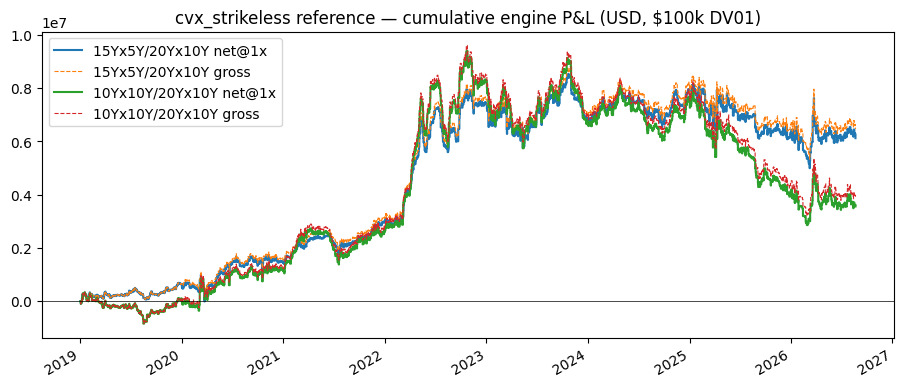

In [15]:
from RVUtils.SFRRVLab.stats import nw_tstat

def _sr(x: pd.Series) -> float:
    sd = float(x.std(ddof=1))
    return float("nan") if sd == 0 else float(x.mean() / sd * np.sqrt(252.0))

DAILY_NET = {}
for p, K in KEEP.items():
    eq, eqg = K["equity"], K["equity_gross"]
    daily_net = eq.diff()
    daily_net.iloc[0] = eq.iloc[0]
    daily_gross = eqg.diff()
    daily_gross.iloc[0] = eqg.iloc[0]
    DAILY_NET[p] = daily_net
    dd = eq - eq.cummax()
    dv01 = K["cfg"].package_dv01_usd
    print(f"pair {p} ({K['cfg'].pair_name}): "
          f"gross {eqg.iloc[-1]:+,.0f} USD ({eqg.iloc[-1] / dv01:+.2f}bp), "
          f"fees {K['fees'].sum():,.0f} USD, net {eq.iloc[-1]:+,.0f} USD "
          f"({eq.iloc[-1] / dv01:+.2f}bp)")
    print(f"  net@1x: ann. Sharpe {_sr(daily_net):+.2f}, NW t {nw_tstat(daily_net):+.2f}, "
          f"maxDD {dd.min():,.0f} USD | gross: ann. Sharpe {_sr(daily_gross):+.2f}, "
          f"NW t {nw_tstat(daily_gross):+.2f}")
    print(f"  certification: corr {K['cert']['corr']:.6f}, terminal gap "
          f"{K['cert']['terminal_gap_usd']:+,.0f} USD ({K['cert']['terminal_gap_bp']:+.2f}bp), "
          f"median |daily diff| {K['cert']['median_abs_daily_diff_bp']:.4f}bp")

fig, ax = plt.subplots(figsize=(11, 4.5))
for p, K in KEEP.items():
    ax.step(K["equity"].index, K["equity"].values, where="post",
            label=f"{K['cfg'].pair_name} net@1x")
    ax.step(K["equity_gross"].index, K["equity_gross"].values, where="post",
            ls="--", lw=0.8, label=f"{K['cfg'].pair_name} gross")
ax.axhline(0, lw=0.5, color="k")
ax.set_title("cvx_strikeless reference — cumulative engine P&L (USD, $100k DV01)")
ax.legend()
fig.autofmt_xdate()
plt.show()

## 5. DSR at the declared suite config count

`n_trials = 4` — the declared §6 cell count across the whole suite (2
strikeless pairs + 1 harvest + 1 dislocation config). The cross-trial
Sharpe dispersion is measured from the two cells THIS notebook runs — an
under-estimate of the 4-cell suite dispersion, and the two pairs share the
20Yx10Y leg so the trials are correlated; both caveats are part of the
number.

In [16]:
from BT.signals.deflated_sharpe import deflated_sharpe

sr_day = {p: float(d.mean() / d.std(ddof=1)) for p, d in DAILY_NET.items()}
var_sr = float(np.var(list(sr_day.values()), ddof=1))
print(f"per-day Sharpes: " + ", ".join(f"{p}={v:+.4f}" for p, v in sr_day.items())
      + f"; cross-cell variance (2 cells, ddof=1) {var_sr:.3e}")
for p, d in DAILY_NET.items():
    out = deflated_sharpe(d.to_numpy(dtype=float), n_trials=4, sr_variance=var_sr)
    print(f"pair {p}: DSR dsr_prob {out['dsr_prob']:.3f}  (sr {out['sr']:+.4f}/day, "
          f"annualised {out['sr_annualised']:+.2f}, sr0 {out['sr0']:+.4f} from "
          f"n_trials=4 with the measured 2-cell variance)")
print("reference number at the declared config count, not a verdict")

per-day Sharpes: A=+0.0249, B=+0.0152; cross-cell variance (2 cells, ddof=1) 4.775e-05
pair A: DSR dsr_prob 0.778  (sr +0.0249/day, annualised +0.40, sr0 +0.0073 from n_trials=4 with the measured 2-cell variance)
pair B: DSR dsr_prob 0.635  (sr +0.0152/day, annualised +0.24, sr0 +0.0073 from n_trials=4 with the measured 2-cell variance)
reference number at the declared config count, not a verdict


## 6. What this run certifies — and does not

Certifies: the strat3 strikeless-vol rule is expressible in the production
engine at full window — the exact hedge tape replays as dated triggers on
explicit-dated OUTRIGHT legs, hedge/roll counts tie out exactly, and the
QDB daily gross P&L reproduces the strat3 unit ledger above the 0.99 bar on
both frozen pairs, with the terminal convention gap stated in USD and bp.
Does NOT certify a strategy: no aliveness claim, no RV-loop registration,
no verdict. The incumbent nulls in the header are the bar any future claim
would have to clear.